a0 = 0.8
a1 = 0.65


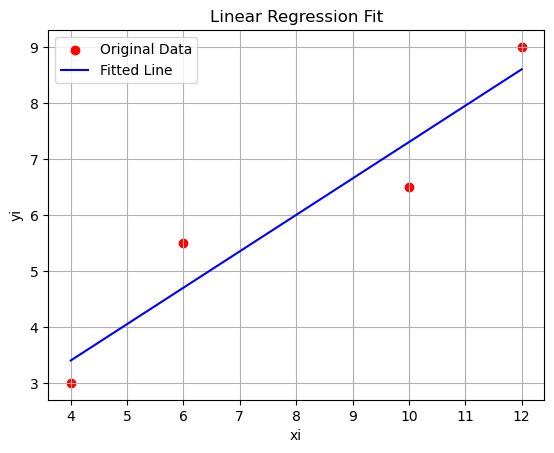

In [1]:
import matplotlib.pyplot as plt
import math

xi=[4,6,10,12]
yi=[3.0,5.5,6.5,9.0]
m=4

xi2=[]
for i in xi:
    xi2.append(i**2)

xiyi=[]
for i in range(len(xi)):
    xiyi.append(xi[i]*yi[i])

sum_xi = sum(xi)
sum_yi = sum(yi)
sum_xi2 = sum(xi2)
sum_xiyi = sum(xiyi)

# Least squares coefficients
a0 = (-(sum_xi*sum_xiyi) + (sum_yi*sum_xi2)) / ((m*sum_xi2)-(sum_xi)**2)
a1 = ((m*sum_xiyi)-(sum_xi*sum_yi)) / ((m*sum_xi2)-(sum_xi)**2)

print("a0 =", a0)
print("a1 =", a1)

# Predicted values
y_pred = []
for i in xi:
    value = a0 + a1*i
    y_pred.append(value)

# ---- Plotting ----
plt.scatter(xi, yi, color='red', label="Original Data")
plt.plot(xi, y_pred, color='blue', label="Fitted Line")

plt.xlabel("xi")
plt.ylabel("yi")
plt.title("Linear Regression Fit")
plt.legend()
plt.grid(True)
plt.show()


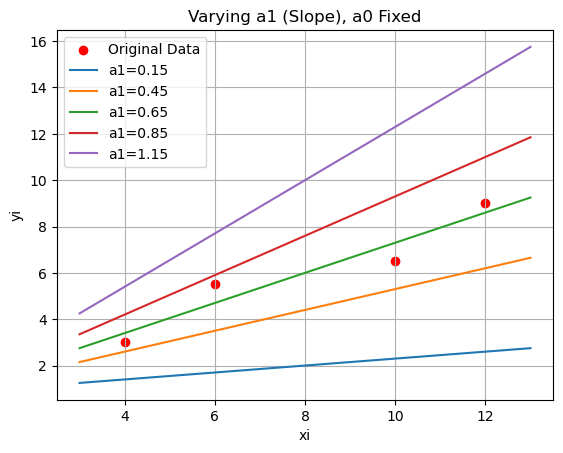

In [2]:
#Case 1: fix a0 and vary a1

# Create smooth x values for better line visualization
x_range = []
start = min(xi) - 1
end = max(xi) + 1
step = 0.1

x = start
while x <= end:
    x_range.append(x)
    x += step

plt.scatter(xi, yi, color='red', label="Original Data")

# Keep a0 fixed
fixed_a0 = a0

# Try different slopes
a1_values = [a1-0.5, a1-0.2, a1, a1+0.2, a1+0.5]

for slope in a1_values:
    y_line = []
    for x in x_range:
        y_line.append(fixed_a0 + slope*x)

    plt.plot(x_range, y_line, label="a1="+str(round(slope,2)))

plt.xlabel("xi")
plt.ylabel("yi")
plt.title("Varying a1 (Slope), a0 Fixed")
plt.legend()
plt.grid(True)
plt.show()


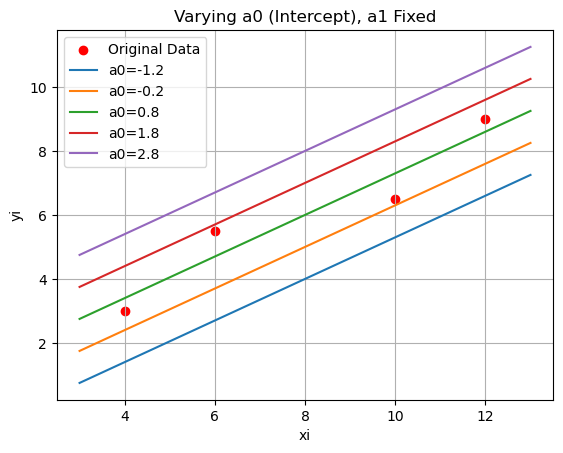

In [3]:
#case 2: Fix a1 and vary a0

plt.scatter(xi, yi, color='red', label="Original Data")

# Keep a1 fixed
fixed_a1 = a1

# Try different intercepts
a0_values = [a0-2, a0-1, a0, a0+1, a0+2]

for intercept in a0_values:
    y_line = []
    for x in x_range:
        y_line.append(intercept + fixed_a1*x)

    plt.plot(x_range, y_line, label="a0="+str(round(intercept,2)))

plt.xlabel("xi")
plt.ylabel("yi")
plt.title("Varying a0 (Intercept), a1 Fixed")
plt.legend()
plt.grid(True)
plt.show()


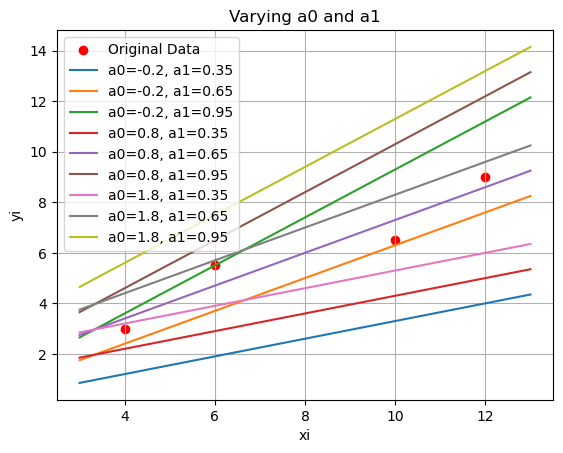

In [4]:
# vary both a0 and a1
# Create smooth x values
x_range = []
start = min(xi) - 1
end = max(xi) + 1
step = 0.1

x = start
while x <= end:
    x_range.append(x)
    x += step

plt.scatter(xi, yi, color='red', label="Original Data")

# Different combinations of a0 and a1
a0_values = [a0-1, a0, a0+1]
a1_values = [a1-0.3, a1, a1+0.3]

for intercept in a0_values:
    for slope in a1_values:
        y_line = []
        for x in x_range:
            y_line.append(intercept + slope*x)

        plt.plot(x_range, y_line,
                 label="a0="+str(round(intercept,2))+
                 ", a1="+str(round(slope,2)))

plt.xlabel("xi")
plt.ylabel("yi")
plt.title("Varying a0 and a1")
plt.legend()
plt.grid(True)
plt.show()


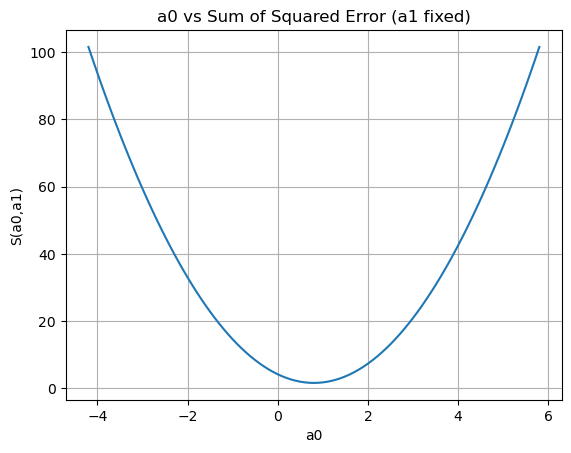

In [5]:
#error surface   using SSE
#Case1:a1 fixed a0 vs S(a0,a1) 
# ---- Cost function ----
def compute_S(a0, a1):
    total = 0
    for i in range(len(xi)):
        error = yi[i] - (a0 + a1*xi[i])
        total += error**2
    return total

# Vary a0, keep a1 fixed
a0_values = []
S_values_a0 = []

start = a0 - 5
end = a0 + 5
step = 0.1

val = start
while val <= end:
    a0_values.append(val)
    S_values_a0.append(compute_S(val, a1))
    val += step

plt.plot(a0_values, S_values_a0)
plt.xlabel("a0")
plt.ylabel("S(a0,a1)")
plt.title("a0 vs Sum of Squared Error (a1 fixed)")
plt.grid(True)
plt.show()


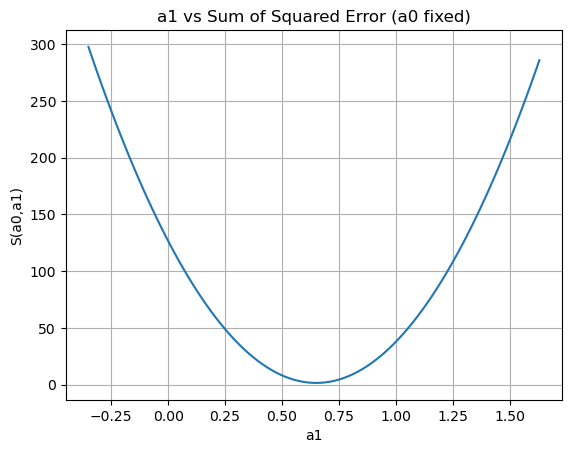

In [6]:
#a0 fix and a1 vs S(a0,a1)

# Vary a1, keep a0 fixed
a1_values = []
S_values_a1 = []

start = a1 - 1
end = a1 + 1
step = 0.02

val = start
while val <= end:
    a1_values.append(val)
    S_values_a1.append(compute_S(a0, val))
    val += step

plt.plot(a1_values, S_values_a1)
plt.xlabel("a1")
plt.ylabel("S(a0,a1)")
plt.title("a1 vs Sum of Squared Error (a0 fixed)")
plt.grid(True)
plt.show()

# S(a0,a1) is a quadratic function in terms of both a0 and a1 and this is 2D so parabolic you can see.
# the bottom of the curve is optimal (a0,a1)

#Quadratic function → Parabola
#Convex quadratic → Unique minimum

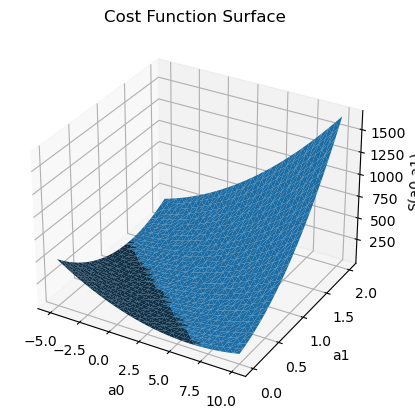

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

xi=[4,6,10,12]
yi=[3.0,5.5,6.5,9.0]

# Cost function
def compute_S(a0, a1):
    total = 0
    for i in range(len(xi)):
        error = yi[i] - (a0 + a1*xi[i])
        total += error**2
    return total

# Small range around reasonable values
a0_values = np.linspace(-5, 10, 30)
a1_values = np.linspace(0, 2, 30)

A0 = []
A1 = []
S_values = []

# Simple nested loop
for a0 in a0_values:
    for a1 in a1_values:
        A0.append(a0)
        A1.append(a1)
        S_values.append(compute_S(a0, a1))

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_trisurf(A0, A1, S_values)

ax.set_xlabel("a0")
ax.set_ylabel("a1")
ax.set_zlabel("S(a0,a1)")
ax.set_title("Cost Function Surface")

plt.show()


In [3]:
import scipy

In [ ]:
#multiple linear regression over generated dataset

In [2]:
pip show scipy

Name: scipy
Version: 1.10.1
Summary: SciPy: Scientific Library for Python
Home-page: https://www.scipy.org
Author: 
Author-email: 
License: BSD
Location: c:\Users\22anj\anaconda3\Lib\site-packages
Requires: numpy
Required-by: datashader, gensim, imbalanced-learn, Pattern, scikit-image, scikit-learn, statsmodels
Note: you may need to restart the kernel to use updated packages.


In [3]:
import sklearn
import scipy
import numpy
print("All imports successful")

All imports successful


In [4]:
from sklearn.datasets import make_blobs
print("make_blobs works")

make_blobs works


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from mpl_toolkits.mplot3d import Axes3D

In [6]:
np.random.seed(42)

In [7]:
# Generate Multi-Feature Data using make_blobs
X, _ = make_blobs(n_samples=200, centers=1, n_features=2, cluster_std=5)
# True parameters (for synthetic target)
true_w = np.array([4, -3])
true_b = 10

# Create target variable
y = X @ true_w + true_b + np.random.randn(200) * 5

y = y.reshape(-1, 1)

# Add bias column for matrix methods
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# True parameters (for synthetic target)
true_w = np.array([4, -3])
true_b = 10

# Create target variable
y = X @ true_w + true_b + np.random.randn(200) * 5

y = y.reshape(-1, 1)

# Add bias column for matrix methods
X_b = np.c_[np.ones((X.shape[0], 1)), X]

In [8]:
# NORMAL EQUATION (THEORETICAL METHOD)
# θ = (XᵀX)^(-1) Xᵀ y

theta_normal = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

print("Normal Equation Parameters:")
print(theta_normal)

Normal Equation Parameters:
[[11.2288149 ]
 [ 4.02426686]
 [-3.10790241]]


In [9]:
#MATRIX INVERSION METHOD (same mathematically, shown stepwise)
XT = X_b.T
XTX = XT @ X_b
XTX_inv = np.linalg.inv(XTX)
XTy = XT @ y

theta_matrix = XTX_inv @ XTy

print("\nMatrix Inversion Parameters:")
print(theta_matrix)


Matrix Inversion Parameters:
[[11.2288149 ]
 [ 4.02426686]
 [-3.10790241]]


In [10]:
#GRADIENT DESCENT METHOD

alpha = 0.001
iterations = 500
m = len(y)

theta_gd = np.zeros((3,1))
cost_history = []

def compute_cost(X, y, theta):
    return (1/(2*m)) * np.sum((X @ theta - y)**2)

for i in range(iterations):
    gradients = (1/m) * X_b.T @ (X_b @ theta_gd - y)
    theta_gd = theta_gd - alpha * gradients
    cost_history.append(compute_cost(X_b, y, theta_gd))

print("\nGradient Descent Parameters:")
print(theta_gd)


Gradient Descent Parameters:
[[ 0.85673316]
 [ 3.80976595]
 [-2.26865128]]


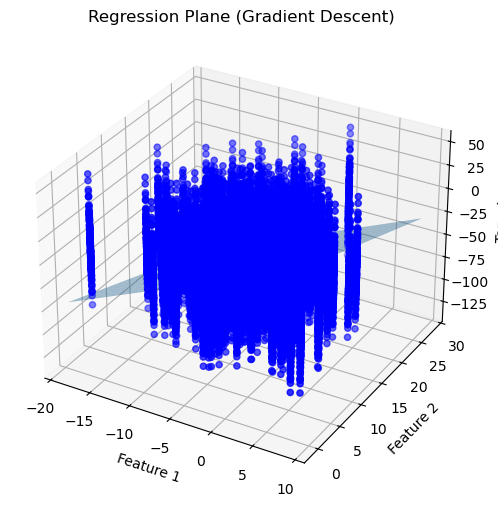

In [11]:
# VISUALIZATION - Regression Plane
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:,0], X[:,1], y, color='blue', label='Data')

# Create grid for plane
x_surf, y_surf = np.meshgrid(
    np.linspace(X[:,0].min(), X[:,0].max(), 20),
    np.linspace(X[:,1].min(), X[:,1].max(), 20)
)

z_surf = (theta_gd[0] +
          theta_gd[1]*x_surf +
          theta_gd[2]*y_surf)

ax.plot_surface(x_surf, y_surf, z_surf, alpha=0.4)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Target")
ax.set_title("Regression Plane (Gradient Descent)")

plt.show()

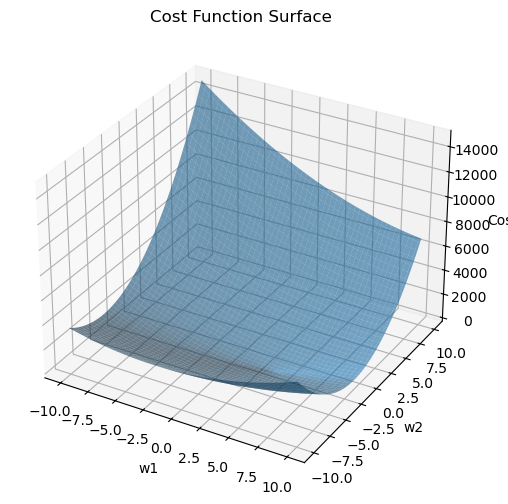

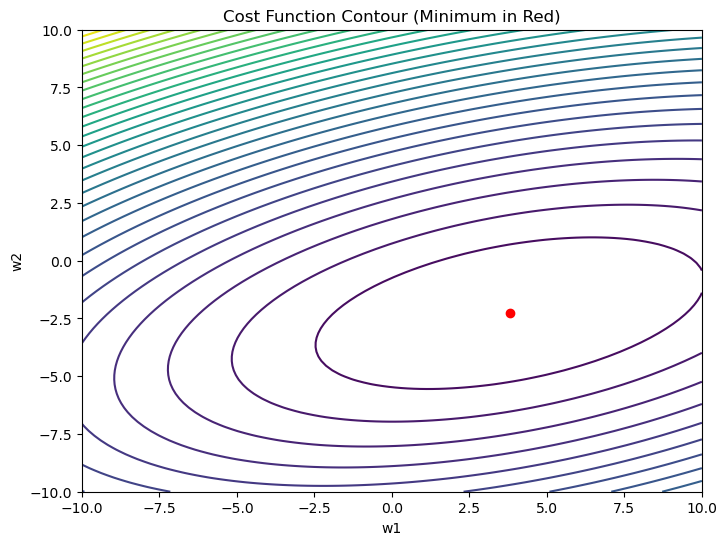

In [14]:
# COST FUNCTION CONTOUR & 3D SURFACE (only w1, w2 fixed b)

# Fix bias from GD
b_fixed = theta_gd[0,0]

w1_range = np.linspace(-10, 10, 100)
w2_range = np.linspace(-10, 10, 100)
W1, W2 = np.meshgrid(w1_range, w2_range)

J_vals = np.zeros(W1.shape)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        theta_temp = np.array([[b_fixed],
                               [W1[i,j]],
                               [W2[i,j]]])
        J_vals[i,j] = compute_cost(X_b, y, theta_temp)

# 3D Surface Plot
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W1, W2, J_vals, alpha=0.6)
ax.set_xlabel("w1")
ax.set_ylabel("w2")
ax.set_zlabel("Cost")
ax.set_title("Cost Function Surface")
plt.show()

# Contour Plot
plt.figure(figsize=(8,6))
plt.contour(W1, W2, J_vals, levels=30)
plt.scatter(theta_gd[1], theta_gd[2], color='red')
plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Cost Function Contour (Minimum in Red)")
plt.show()

NameError: name 'theta_path' is not defined

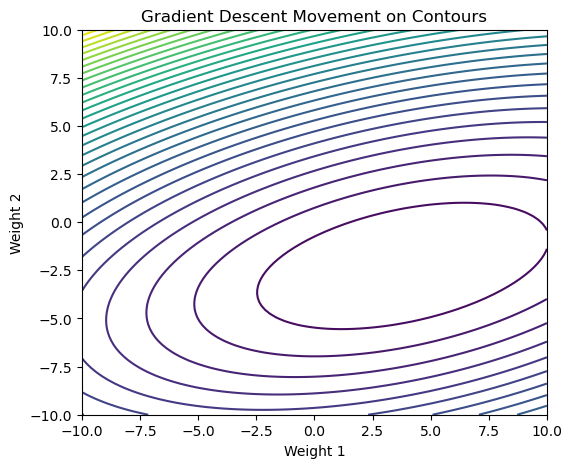

In [15]:
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots(figsize=(6,5))
ax.contour(W1, W2, J_vals, levels=30)

line, = ax.plot([], [], 'r.-')

ax.set_xlabel("Weight 1")
ax.set_ylabel("Weight 2")
ax.set_title("Gradient Descent Movement on Contours")

def update(frame):
    x = theta_path[:frame,1,0]
    y = theta_path[:frame,2,0]
    line.set_data(x, y)
    return line,

ani = FuncAnimation(fig, update, frames=len(theta_path), interval=200)
plt.show()

Final Parameters:
[[0.94221362]
 [3.264872  ]
 [2.30251038]]


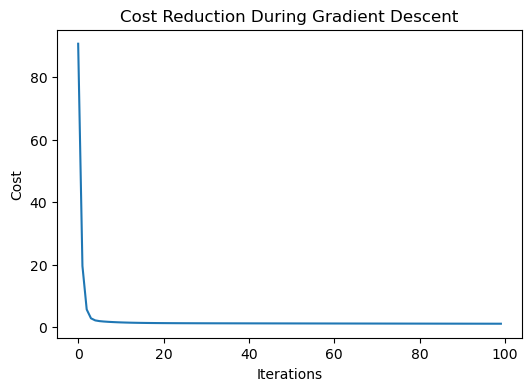

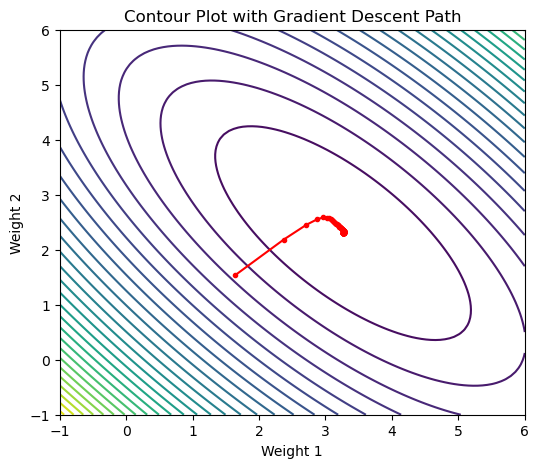

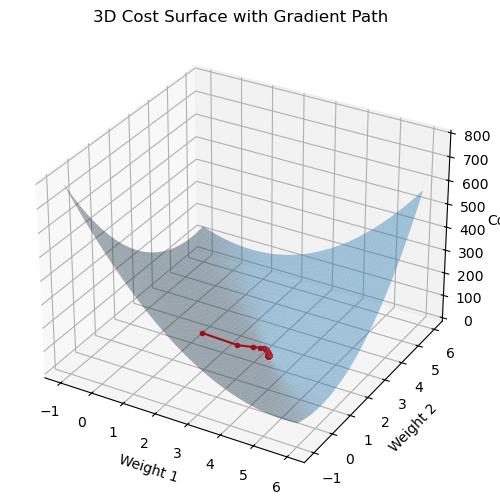

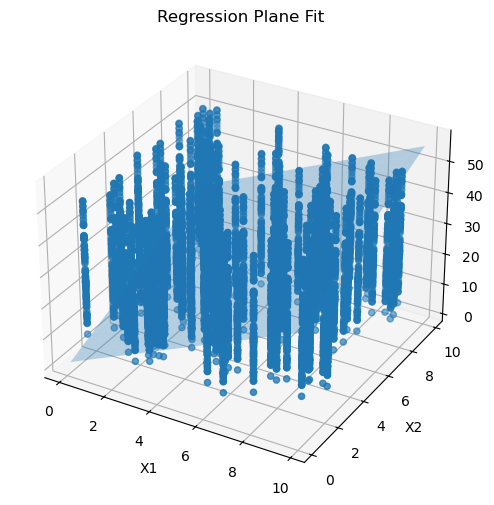

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ===============================
# 1. Create Synthetic Data
# ===============================

np.random.seed(42)

m = 100
X = np.random.rand(m, 2) * 10

true_theta = np.array([[4], [3], [2]])  # bias=4, w1=3, w2=2
noise = np.random.randn(m, 1)

X_b = np.c_[np.ones((m,1)), X]
y = X_b @ true_theta + noise


# ===============================
# 2. Cost Function
# ===============================

def compute_cost(X, y, theta):
    m = len(y)
    return (1/(2*m)) * np.sum((X @ theta - y)**2)


# ===============================
# 3. Gradient Descent
# ===============================

def gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = []
    theta_path = []

    for _ in range(iterations):
        gradients = (1/m) * X.T @ (X @ theta - y)
        theta = theta - alpha * gradients

        cost_history.append(compute_cost(X, y, theta))
        theta_path.append(theta.copy())

    return theta, cost_history, theta_path


# ===============================
# 4. Train Model
# ===============================

theta_initial = np.zeros((3,1))

theta_gd, cost_history, theta_path = gradient_descent(
    X_b, y, theta_initial, alpha=0.01, iterations=100
)

theta_path = np.array(theta_path)

print("Final Parameters:")
print(theta_gd)


# ===============================
# 5. Plot Cost vs Iterations
# ===============================

plt.figure(figsize=(6,4))
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Reduction During Gradient Descent")
plt.show()


# ===============================
# 6. Create Cost Surface Grid
# ===============================

w1_vals = np.linspace(-1, 6, 100)
w2_vals = np.linspace(-1, 6, 100)

W1, W2 = np.meshgrid(w1_vals, w2_vals)

J_vals = np.zeros(W1.shape)

b_fixed = theta_gd[0,0]

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        theta_temp = np.array([[b_fixed],
                               [W1[i,j]],
                               [W2[i,j]]])
        J_vals[i,j] = compute_cost(X_b, y, theta_temp)


# ===============================
# 7. Contour Plot + GD Path
# ===============================

plt.figure(figsize=(6,5))
plt.contour(W1, W2, J_vals, levels=30)

plt.plot(theta_path[:,1,0],
         theta_path[:,2,0],
         'r.-')

plt.xlabel("Weight 1")
plt.ylabel("Weight 2")
plt.title("Contour Plot with Gradient Descent Path")
plt.show()


# ===============================
# 8. 3D Surface Plot + GD Path
# ===============================

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(W1, W2, J_vals, alpha=0.4)

cost_path = [compute_cost(X_b, y, t) for t in theta_path]

ax.plot(theta_path[:,1,0],
        theta_path[:,2,0],
        cost_path,
        'r.-')

ax.set_xlabel("Weight 1")
ax.set_ylabel("Weight 2")
ax.set_zlabel("Cost")
ax.set_title("3D Cost Surface with Gradient Path")

plt.show()


# ===============================
# 9. Regression Plane Visualization
# ===============================

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:,0], X[:,1], y)

x_surf, y_surf = np.meshgrid(
    np.linspace(X[:,0].min(), X[:,0].max(), 20),
    np.linspace(X[:,1].min(), X[:,1].max(), 20)
)

z_surf = (theta_gd[0,0]
          + theta_gd[1,0]*x_surf
          + theta_gd[2,0]*y_surf)

ax.plot_surface(x_surf, y_surf, z_surf, alpha=0.3)

ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("y")
ax.set_title("Regression Plane Fit")

plt.show()

In [2]:
#MLR Dataset generator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

In [3]:
x,y=datasets.make_regression(n_samples=100,n_features=5)
df=pd.DataFrame(x)

In [4]:
df

,0,1,2,3,4
0,1.501197,0.147161,-0.091219,-0.476698,-0.705299
1,1.151922,-0.790671,-0.948930,0.557701,0.809642
2,0.429557,-1.307938,0.832010,-0.077130,2.215409
3,-0.514706,0.922927,0.198070,1.598818,-0.037394
4,-0.517737,1.780069,1.147929,0.494440,-0.442033
...,...,...,...,...,...
95,-0.482047,2.399195,0.388896,-2.145008,0.118080
96,-0.589209,0.473882,-0.671709,1.069947,1.335544
97,-1.983453,-1.154859,1.007012,-1.859707,-0.622176
98,-0.263421,-0.900739,0.193469,-0.540177,2.322333


In [5]:
print(y.shape)
y = y.reshape(-1, 1)
print(y.shape)
X_b = np.c_[np.ones((100, 1)), df]
print(X_b.shape)
print(df.shape)

(100,)
(100, 1)
(100, 6)
(100, 5)


In [6]:
XTX = X_b.T @ X_b #xtranspose x
XTy = X_b.T @ y #xtranspose y
theta_reg = np.linalg.inv(XTX) @ XTy #inverse of xtranspose x
print("Calculated (b0,b1,b2,b3,b4,b5):", theta_reg.flatten())

Calculated (b0,b1,b2,b3,b4,b5): [-8.88178420e-16  3.93530539e+01  6.61015494e+01  6.61890251e+01
  3.05784746e+01  2.74335216e+01]


In [7]:
y_pred = X_b @ theta_reg #predict using coefficients
errors = y - y_pred # calculate error
error_sum_square = np.sum(errors**2) # square error and then sum
print("Total Residual Error:", error_sum_square)

Total Residual Error: 5.715563498881743e-26


In [8]:
_, s_values, _ = np.linalg.svd(X_b) # svd to check independence feature
rank_manual = np.sum(s_values > 1e-10) # rank is count value that are not effectively zero
print("Matrix Rank:", rank_manual)

Matrix Rank: 6


In [9]:
print("Singular Values (s):", s_values) #provide spread of data in each feature direction

Singular Values (s): [11.67012757 11.03057805 10.31946866  9.86998287  9.1519621   8.47233772]


In [10]:
theta_official, res_official, rank_official, s_official = np.linalg.lstsq(X_b, y, rcond=None)
# theta_reg, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=None)
print(f"Weights Match?   {np.allclose(theta_reg, theta_official)}")
print(f"Residuals Match? {np.allclose(error_sum_square, res_official)}")
print(f"Rank Matches?    {rank_manual == rank_official}")
print(f"S-Values Match?  {np.allclose(s_values, s_official)}")
print(res_official)
print(error_sum_square)

Weights Match?   True
Residuals Match? True
Rank Matches?    True
S-Values Match?  True
[8.77670576e-26]
5.715563498881743e-26


In [11]:
theta_reg, error_sum_square, rank, s = np.linalg.lstsq(X_b, y, rcond=None)
print(theta_reg)
print(error_sum_square)
print(rank)
print(s)

[[2.87047861e-13]
 [3.93530539e+01]
 [6.61015494e+01]
 [6.61890251e+01]
 [3.05784746e+01]
 [2.74335216e+01]]
[8.77670576e-26]
6
[11.67012757 11.03057805 10.31946866  9.86998287  9.1519621   8.47233772]


Regular Method - MSE: 0.00, R2: 1.0000


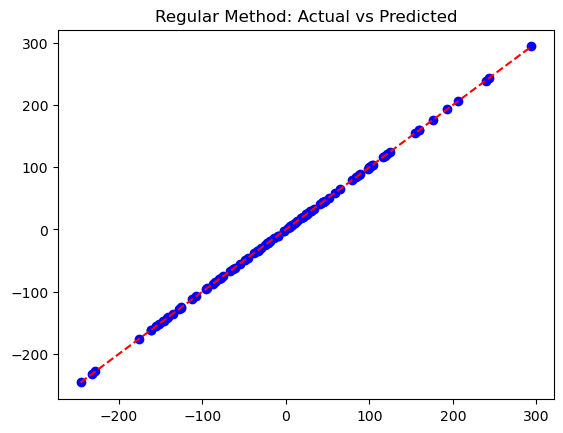

In [12]:
from sklearn.metrics import mean_squared_error,r2_score,root_mean_squared_error,accuracy_score
print(f"Regular Method - MSE: {mean_squared_error(y, y_pred):.2f}, R2: {r2_score(y, y_pred):.4f}")
# print(f"Regular Method - RMSE: {root_mean_squared_error(y, y_pred):.2f}")
plt.scatter(y, y_pred, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title("Regular Method: Actual vs Predicted")
plt.show()

In [13]:
#iterative gradient descent method
# Step 1: Initialize parameters with random numbers.
# Step 2: Calculate the Prediction Error.
# Step 3: Calculate the Gradient (the direction of the slope).
# Step 4: Update slope and intercepts: new_theta=old_theta-(learning_rate x gradient)
# Step 5: Repeat 1000 times.

In [14]:
X_b

array([[ 1.00000000e+00,  1.50119728e+00,  1.47160960e-01,
        -9.12188988e-02, -4.76698373e-01, -7.05298860e-01],
       [ 1.00000000e+00,  1.15192188e+00, -7.90671345e-01,
        -9.48929988e-01,  5.57700634e-01,  8.09642414e-01],
       [ 1.00000000e+00,  4.29556883e-01, -1.30793843e+00,
         8.32010381e-01, -7.71301691e-02,  2.21540932e+00],
       [ 1.00000000e+00, -5.14705667e-01,  9.22927101e-01,
         1.98070121e-01,  1.59881767e+00, -3.73942545e-02],
       [ 1.00000000e+00, -5.17736586e-01,  1.78006912e+00,
         1.14792943e+00,  4.94440360e-01, -4.42032512e-01],
       [ 1.00000000e+00, -1.36419241e+00,  1.67792576e+00,
        -1.35817089e+00,  6.10192416e-01, -1.29156815e+00],
       [ 1.00000000e+00, -1.23869122e+00, -8.02313604e-01,
         5.32502045e-01,  4.51417994e-01, -3.74468530e-01],
       [ 1.00000000e+00,  6.72171756e-01,  5.80493115e-01,
        -1.59995067e+00,  1.07190665e+00,  9.69029166e-01],
       [ 1.00000000e+00, -5.76206995e-01, -1.315

In [15]:
learning_rate = 0.1
n_iterations = 1000
m = len(y) # number of samples
theta_gd = np.random.randn(6, 1) # 5 features + 1 intercept
print(theta_gd)
for i in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta_gd) - y) # 2/m->size of our dataset doesn't make the gradient move too fast.
    # multiply the Error by the Features(X_b) (X_b.dot(theta_gd) - y)->error term where X_b.theta_gd is y cap
    theta_gd -= learning_rate * gradients

y_pred_gd = X_b.dot(theta_gd)
print(theta_gd)


[[-0.4788313 ]
 [ 1.29016443]
 [-1.25736972]
 [ 1.40194128]
 [-0.55526362]
 [-0.30742322]]
[[-3.32851254e-15]
 [ 3.93530539e+01]
 [ 6.61015494e+01]
 [ 6.61890251e+01]
 [ 3.05784746e+01]
 [ 2.74335216e+01]]


In [16]:
print(f"Gradient Descent - MSE: {mean_squared_error(y, y_pred_gd):.2f}, R2: {r2_score(y, y_pred_gd):.4f}")

Gradient Descent - MSE: 0.00, R2: 1.0000


In [17]:
from sklearn.linear_model import SGDRegressor
from mpl_toolkits.mplot3d import Axes3D

In [27]:
model=SGDRegressor(learning_rate='constant',eta0=0.01,max_iter=10,tol=0.1,warm_start=True)
iterations=1000
losses=[]

model.partial_fit(X_b,y)
y_red=model.predict(X_b)
mse=mean_squared_error(y,y_red)
losses.append(mse)

print(f"Gradient Descent - MSE1: {mean_squared_error(y, y_red):.2f}, 1R2: {r2_score(y, y_red):.4f}")


Gradient Descent - MSE1: 1604.03, 1R2: 0.8565


c:\Users\22anj\anaconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [43]:
losses=np.array(losses)
losses.shape
losses.reshape(1)



array([1604.03032836])

In [38]:
#library

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_b, y)
y_pred_lib = model.predict(X_b)


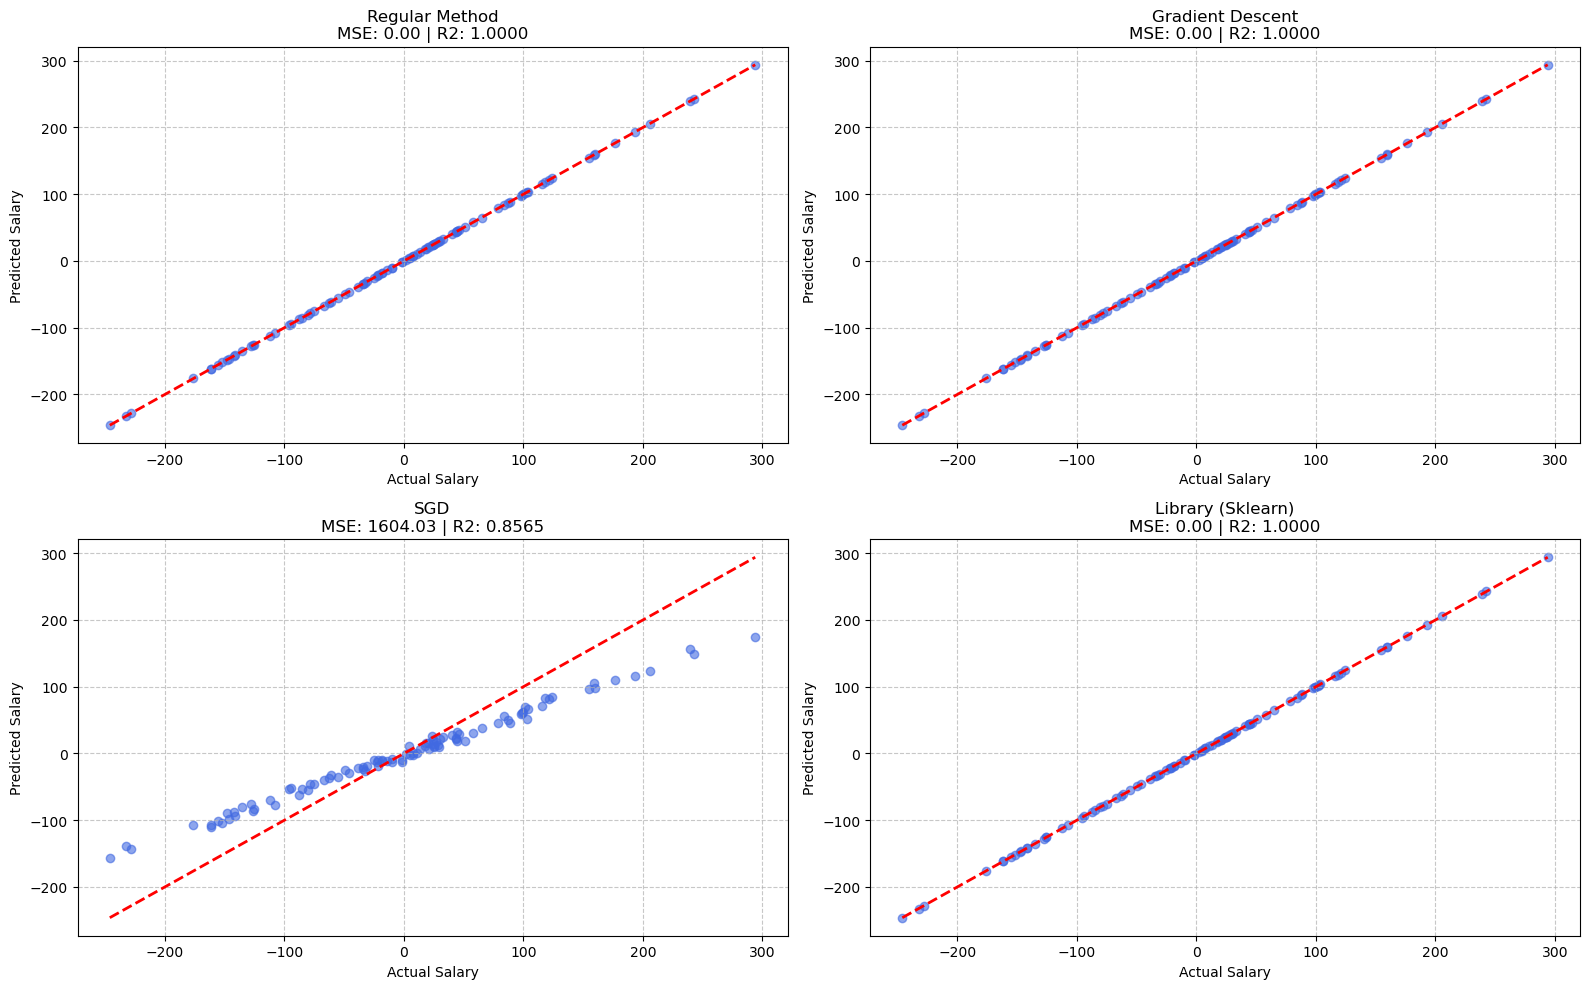

In [39]:
methods = [
    ("Regular Method", y_pred),
    ("Gradient Descent", y_pred_gd),
    ("SGD",y_red),
    ("Library (Sklearn)", y_pred_lib)
]

plt.figure(figsize=(16, 10))

for i, (name, pred) in enumerate(methods, 1):
    mse = mean_squared_error(y, pred)
    r2 = r2_score(y, pred)
    
    plt.subplot(2, 2, i)
    plt.scatter(y, pred, alpha=0.6, color='royalblue')
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # 45-degree line
    plt.title(f"{name}\nMSE: {mse:.2f} | R2: {r2:.4f}")
    plt.xlabel("Actual Salary")
    plt.ylabel("Predicted Salary")
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()